# Notebook 2 — Feature Engineering
## Source : MODIS MOD13Q1 — NDVI 16 jours
## Zone : Mandoul, Tchad | Période : 2019-2023
### Objectif : construire les features ML depuis la série temporelle NDVI

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
df = pd.read_csv('ndvi-mandoul-2019-2023-MOD13Q1-061-results.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(104, 29)
['Category', 'ID', 'Latitude', 'Longitude', 'Date', 'MODIS_Tile', 'MOD13Q1_061_Line_Y_250m', 'MOD13Q1_061_Sample_X_250m', 'MOD13Q1_061__250m_16_days_NDVI', 'MOD13Q1_061__250m_16_days_VI_Quality', 'MOD13Q1_061__250m_16_days_VI_Quality_bitmask', 'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND', 'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_VI_Usefulness', 'MOD13Q1_061__250m_16_days_VI_Quality_VI_Usefulness_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Aerosol_Quantity', 'MOD13Q1_061__250m_16_days_VI_Quality_Aerosol_Quantity_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Adjacent_cloud_detected', 'MOD13Q1_061__250m_16_days_VI_Quality_Adjacent_cloud_detected_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Atmosphere_BRDF_Correction', 'MOD13Q1_061__250m_16_days_VI_Quality_Atmosphere_BRDF_Correction_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Mixed_Clouds', 'MOD13Q1_061__250m_16_days_VI_Quality_Mixed_Clouds_De

## Nettoyer les données

In [13]:
df_clean = df[[
    'Date',
    'MOD13Q1_061__250m_16_days_NDVI',
    'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND_Description'
]].copy()

df_clean.columns = [
    'date',
    'ndvi',
    'qualite'
]

In [ ]:
print(df_clean['qualite'].unique())

['Pixel produced, but most probably cloudy'
 'VI produced with good quality' 'VI produced, but check other QA']


In [14]:
df_clean = df_clean[df_clean['qualite'].isin(['VI produced with good quality', 'VI produced, but check other QA'])]

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values(by='date')

df_clean = df_clean.reset_index(drop=True)

print(df_clean)

         date    ndvi                          qualite
0  2019-07-28  0.7217    VI produced with good quality
1  2019-08-13  0.7531    VI produced with good quality
2  2019-08-29  0.7363  VI produced, but check other QA
3  2019-09-14  0.6776  VI produced, but check other QA
4  2019-10-16  0.7289    VI produced with good quality
..        ...     ...                              ...
86 2023-10-16  0.6626    VI produced with good quality
87 2023-11-01  0.6344  VI produced, but check other QA
88 2023-11-17  0.5005    VI produced with good quality
89 2023-12-03  0.4042    VI produced with good quality
90 2023-12-19  0.4005    VI produced with good quality

[91 rows x 3 columns]


### Garder seulement les mois agricoles

In [15]:
df_clean = df_clean[df_clean['date'].dt.month.isin([6, 7, 8, 9, 10, 11, 12])]
df_clean = df_clean.reset_index(drop=True)
print(df_clean)

         date    ndvi                          qualite
0  2019-07-28  0.7217    VI produced with good quality
1  2019-08-13  0.7531    VI produced with good quality
2  2019-08-29  0.7363  VI produced, but check other QA
3  2019-09-14  0.6776  VI produced, but check other QA
4  2019-10-16  0.7289    VI produced with good quality
5  2019-11-01  0.6923    VI produced with good quality
6  2019-11-17  0.6012    VI produced with good quality
7  2019-12-03  0.5303    VI produced with good quality
8  2019-12-19  0.4228    VI produced with good quality
9  2020-06-09  0.4468  VI produced, but check other QA
10 2020-06-25  0.5075    VI produced with good quality
11 2020-07-27  0.6330  VI produced, but check other QA
12 2020-08-28  0.6847    VI produced with good quality
13 2020-09-29  0.6685  VI produced, but check other QA
14 2020-10-15  0.7289    VI produced with good quality
15 2020-10-31  0.6240    VI produced with good quality
16 2020-11-16  0.5677    VI produced with good quality
17 2020-12

## Visualisation de la dataset

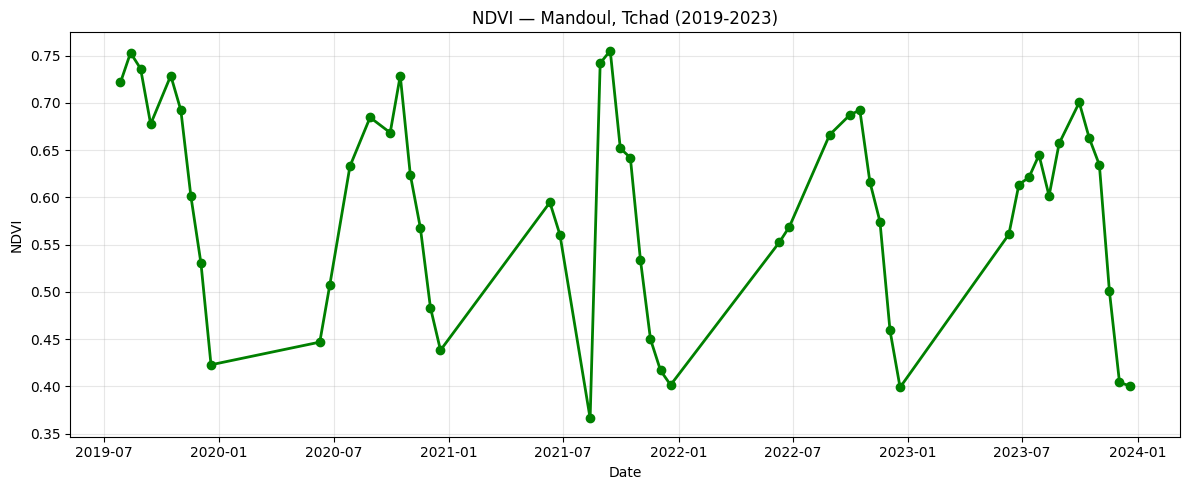

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_clean["date"], df_clean["ndvi"], "o-", color="green", linewidth=2)
plt.title("NDVI — Mandoul, Tchad (2019-2023)")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ndvi_mandoul.png", dpi=150)
plt.show()

## Calcul des premières features

In [16]:
df_clean['annee'] = df_clean['date'].dt.year
df_clean['mois'] = df_clean['date'].dt.month
print(df_clean.head(10))

        date    ndvi                          qualite  annee  mois
0 2019-07-28  0.7217    VI produced with good quality   2019     7
1 2019-08-13  0.7531    VI produced with good quality   2019     8
2 2019-08-29  0.7363  VI produced, but check other QA   2019     8
3 2019-09-14  0.6776  VI produced, but check other QA   2019     9
4 2019-10-16  0.7289    VI produced with good quality   2019    10
5 2019-11-01  0.6923    VI produced with good quality   2019    11
6 2019-11-17  0.6012    VI produced with good quality   2019    11
7 2019-12-03  0.5303    VI produced with good quality   2019    12
8 2019-12-19  0.4228    VI produced with good quality   2019    12
9 2020-06-09  0.4468  VI produced, but check other QA   2020     6


In [17]:
features = df_clean.groupby('annee')['ndvi'].agg(
    ndvi_max   = 'max',
    ndvi_mean  = 'mean',
    ndvi_min   = 'min',
    ndvi_integral = 'sum'
).reset_index()

print(features)

   annee  ndvi_max  ndvi_mean  ndvi_min  ndvi_integral
0   2019    0.7531   0.651578    0.4228         5.8642
1   2020    0.7289   0.578270    0.4382         5.7827
2   2021    0.7553   0.555891    0.3661         6.1148
3   2022    0.6925   0.579589    0.3989         5.2163
4   2023    0.7005   0.583492    0.4005         7.0019


### Ajout des features par phase

In [19]:
vg  = df_clean[df_clean['mois'].isin([7, 8])].groupby('annee')['ndvi'].agg(
    ndvi_mean_vg = 'mean'
).reset_index()

fl  = df_clean[df_clean['mois'].isin([9])].groupby('annee')['ndvi'].agg(
    ndvi_max_fl = 'max'
).reset_index()

sn  = df_clean[df_clean['mois'].isin([10, 11])].groupby('annee')['ndvi'].agg(
    ndvi_mean_sn = 'mean'
).reset_index()

print(vg)
print(fl)
print(sn)

   annee  ndvi_mean_vg
0   2019      0.737033
1   2020      0.658850
2   2021      0.554100
3   2022      0.666300
4   2023      0.631200
   annee  ndvi_max_fl
0   2019       0.6776
1   2020       0.6685
2   2021       0.7553
3   2022       0.6872
4   2023       0.7005
   annee  ndvi_mean_sn
0   2019      0.674133
1   2020      0.640200
2   2021      0.542000
3   2022      0.627767
4   2023      0.599167


### Fusion des features


In [21]:
df_merge_1= pd.merge(features, vg, on='annee')

df_merge_2 = pd.merge(df_merge_1, fl, on='annee')

df_features = pd.merge(df_merge_2, sn, on='annee')

print(df_features)

   annee  ndvi_max  ndvi_mean  ndvi_min  ndvi_integral  ndvi_mean_vg  \
0   2019    0.7531   0.651578    0.4228         5.8642      0.737033   
1   2020    0.7289   0.578270    0.4382         5.7827      0.658850   
2   2021    0.7553   0.555891    0.3661         6.1148      0.554100   
3   2022    0.6925   0.579589    0.3989         5.2163      0.666300   
4   2023    0.7005   0.583492    0.4005         7.0019      0.631200   

   ndvi_max_fl  ndvi_mean_sn  
0       0.6776      0.674133  
1       0.6685      0.640200  
2       0.7553      0.542000  
3       0.6872      0.627767  
4       0.7005      0.599167  


# Chargement et exploration des données FAO

In [22]:
df_fao = pd.read_csv('FAOSTAT_data_en_3-22-2026.csv')
print(df_fao.shape)
print(df_fao.columns.tolist())
print(df_fao)

(10, 15)
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']
  Domain Code                        Domain  Area Code (M49)  Area  \
0         QCL  Crops and livestock products              148  Chad   
1         QCL  Crops and livestock products              148  Chad   
2         QCL  Crops and livestock products              148  Chad   
3         QCL  Crops and livestock products              148  Chad   
4         QCL  Crops and livestock products              148  Chad   
5         QCL  Crops and livestock products              148  Chad   
6         QCL  Crops and livestock products              148  Chad   
7         QCL  Crops and livestock products              148  Chad   
8         QCL  Crops and livestock products              148  Chad   
9         QCL  Crops and livestock products              148  Chad   

   Element Code Element  Item Code (CPC

## Préparer la variable cible

In [24]:
df_fao = df_fao[[
    'Year',
    'Value'
]].copy()

In [28]:
df_fao = df_fao.groupby('Year').agg(
    Value_mean = ('Value', 'mean')
).reset_index()

df_fao['Value_mean'] = df_fao['Value_mean'] * 0.001

df_fao.columns = [
    'annee',
    'rendement_t_ha'
]

print(df_fao)

   annee  rendement_t_ha
0   2019         0.73825
1   2020         0.71570
2   2021         0.67445
3   2022         0.71315
4   2023         0.67580


In [33]:
df_fao.to_csv('dataset_fao_mandoul.csv', index=False)
print(f"✅ {len(df_fao)} lignes sauvegardées")

✅ 5 lignes sauvegardées


## Dataset final (Fusion des deux features)

In [29]:
df_final = pd.merge(df_features, df_fao, on='annee')
print(df_final)

   annee  ndvi_max  ndvi_mean  ndvi_min  ndvi_integral  ndvi_mean_vg  \
0   2019    0.7531   0.651578    0.4228         5.8642      0.737033   
1   2020    0.7289   0.578270    0.4382         5.7827      0.658850   
2   2021    0.7553   0.555891    0.3661         6.1148      0.554100   
3   2022    0.6925   0.579589    0.3989         5.2163      0.666300   
4   2023    0.7005   0.583492    0.4005         7.0019      0.631200   

   ndvi_max_fl  ndvi_mean_sn  rendement_t_ha  
0       0.6776      0.674133         0.73825  
1       0.6685      0.640200         0.71570  
2       0.7553      0.542000         0.67445  
3       0.6872      0.627767         0.71315  
4       0.7005      0.599167         0.67580  


In [32]:
df_final.to_csv('dataset_ml_mandoul.csv', index=False)
print(f"✅ {len(df_final)} lignes sauvegardées")

✅ 5 lignes sauvegardées
